In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
import warnings
warnings.filterwarnings('ignore')
import os

df = pd.read_csv('../data/mouna_dataset.csv')
print(f"Dataset loaded: {df.shape}")
print(f"High risk rate: {df['high_risk'].mean()*100:.1f}%")

Dataset loaded: (2000, 20)
High risk rate: 14.3%


In [2]:
def engineer_features(df):
    d = df.copy()

    # ── interaction features ─────────────────────────────
    # reproductive years = years of estrogen exposure
    d['reproductive_years'] = d['age_menopause'] - d['age_menarche']

    # age × BMI interaction (obesity risk amplifies with age)
    d['age_bmi_interaction'] = d['age'] * d['bmi'] / 100

    # biomarker combined score
    d['biomarker_score'] = (
        np.log1p(d['ggt']) * 0.6 +
        np.log1p(d['alt']) * 0.4
    )

    # GGT above normal threshold (>40 U/L)
    d['ggt_elevated'] = (d['ggt'] > 40).astype(int)

    # ALT above normal threshold (>35 U/L)
    d['alt_elevated'] = (d['alt'] > 35).astype(int)

    # both biomarkers elevated
    d['both_elevated'] = (d['ggt_elevated'] & d['alt_elevated']).astype(int)

    # family risk score (weighted)
    d['family_risk_score'] = (
        d['brca_mutation'] * 5 +
        d['family_history_1st'] * 2 +
        d['family_history_2nd'] * 1
    )

    # hormonal exposure score
    d['hormonal_score'] = (
        d['hrt_use'] * 2 +
        d['oral_contraceptive_use'] * 1 +
        (d['age_menarche'] <= 11).astype(int) * 1 +
        (d['age_menopause'] >= 55).astype(int) * 1
    )

    # lifestyle risk score
    d['lifestyle_score'] = (
        d['alcohol_drinks_week'] * 1.5 +
        d['smoking'] * 1 +
        (2 - d['physical_activity']) * 1
    )

    # nulliparous flag (never pregnant — higher risk)
    d['nulliparous'] = (d['parity'] == 0).astype(int)

    # age category
    d['age_group'] = pd.cut(d['age'],
        bins=[29, 40, 50, 60, 75],
        labels=[0, 1, 2, 3]).astype(int)

    # BMI category
    d['bmi_category'] = pd.cut(d['bmi'],
        bins=[0, 18.5, 25, 30, 100],
        labels=[0, 1, 2, 3]).astype(int)

    return d

df_eng = engineer_features(df)

new_features = ['reproductive_years', 'age_bmi_interaction',
                'biomarker_score', 'ggt_elevated', 'alt_elevated',
                'both_elevated', 'family_risk_score', 'hormonal_score',
                'lifestyle_score', 'nulliparous', 'age_group', 'bmi_category']

print(f"Original features:    {df.shape[1]}")
print(f"Engineered features:  {df_eng.shape[1]}")
print(f"New features added:   {len(new_features)}")
print(f"\nNew feature preview:")
print(df_eng[new_features].describe().round(2).T[['mean','std','min','max']])

Original features:    20
Engineered features:  32
New features added:   12

New feature preview:
                      mean   std    min    max
reproductive_years   37.03  4.06  25.00  48.00
age_bmi_interaction  14.13  4.08   5.49  29.32
biomarker_score       2.91  0.32   1.95   3.99
ggt_elevated          0.04  0.20   0.00   1.00
alt_elevated          0.05  0.22   0.00   1.00
both_elevated         0.00  0.03   0.00   1.00
family_risk_score     0.67  1.14   0.00   8.00
hormonal_score        1.02  1.01   0.00   5.00
lifestyle_score       2.52  1.82   0.00   7.50
nulliparous           0.14  0.35   0.00   1.00
age_group             1.68  1.01   0.00   3.00
bmi_category          1.90  0.85   0.00   3.00


In [3]:
# prepare features and target
feature_cols = [c for c in df_eng.columns
                if c not in ['risk_score', 'high_risk']]
X = df_eng[feature_cols]
y = df_eng['high_risk']

# mutual information scores
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({
    'feature': feature_cols,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

print("Feature Importance (Mutual Information):")
print("="*45)
for _, row in mi_df.iterrows():
    bar = '█' * int(row['mi_score'] * 200)
    print(f"  {row['feature']:<28} {row['mi_score']:.4f}  {bar}")

Feature Importance (Mutual Information):
  age_bmi_interaction          0.0646  ████████████
  family_risk_score            0.0621  ████████████
  age_group                    0.0618  ████████████
  age                          0.0573  ███████████
  prior_benign_biopsy          0.0334  ██████
  brca_mutation                0.0245  ████
  hrt_use                      0.0214  ████
  lifestyle_score              0.0214  ████
  family_history_1st           0.0184  ███
  bmi_category                 0.0178  ███
  alcohol_drinks_week          0.0160  ███
  smoking                      0.0150  ██
  age_menarche                 0.0136  ██
  hormonal_score               0.0082  █
  breastfeed_years             0.0068  █
  nulliparous                  0.0065  █
  alt                          0.0054  █
  bmi                          0.0051  █
  alt_elevated                 0.0036  
  biomarker_score              0.0029  
  age_menopause                0.0009  
  breastfeeding                0.000

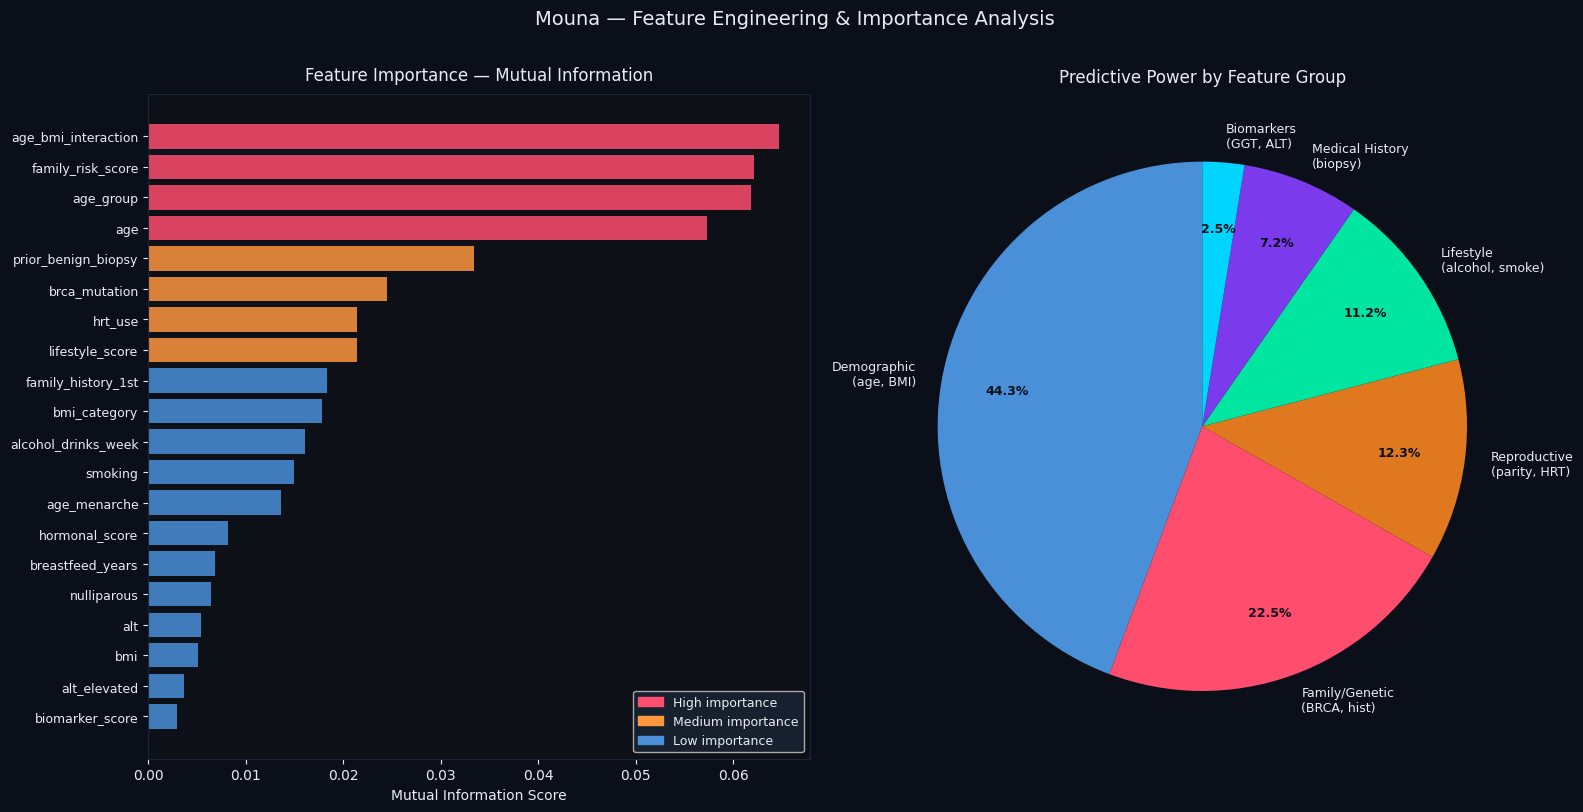

Saved to outputs/feature_importance.png

Selected 21 features for modeling
Saved to data/mouna_engineered.csv


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor('#0a0f1a')

# ── plot 1: feature importance bar chart ─────────────────
ax = axes[0]
ax.set_facecolor('#0d1117')

top_features = mi_df.head(20)
colors_bar = ['#ff4d6d' if s > 0.04 else
              '#ff9640' if s > 0.02 else
              '#4A90D9' for s in top_features['mi_score']]

bars = ax.barh(range(len(top_features)),
               top_features['mi_score'],
               color=colors_bar, alpha=0.85, edgecolor='none')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'], fontsize=9,
                   color='#e8edf5')
ax.set_xlabel('Mutual Information Score', color='#e8edf5')
ax.set_title('Feature Importance — Mutual Information',
             color='#e8edf5', fontsize=12, pad=10)
ax.tick_params(colors='#e8edf5')
for spine in ax.spines.values():
    spine.set_edgecolor('#1a2535')
ax.invert_yaxis()

# legend
from matplotlib.patches import Patch
legend = [Patch(color='#ff4d6d', label='High importance'),
          Patch(color='#ff9640', label='Medium importance'),
          Patch(color='#4A90D9', label='Low importance')]
ax.legend(handles=legend, facecolor='#1a2535',
          labelcolor='#e8edf5', fontsize=9)

# ── plot 2: feature groups comparison ────────────────────
ax2 = axes[1]
ax2.set_facecolor('#0d1117')

groups = {
    'Demographic\n(age, BMI)':     mi_df[mi_df['feature'].isin(
        ['age','bmi','age_group','bmi_category','age_bmi_interaction']
    )]['mi_score'].sum(),
    'Family/Genetic\n(BRCA, hist)': mi_df[mi_df['feature'].isin(
        ['brca_mutation','family_history_1st',
         'family_history_2nd','family_risk_score']
    )]['mi_score'].sum(),
    'Reproductive\n(parity, HRT)': mi_df[mi_df['feature'].isin(
        ['parity','breastfeeding','breastfeed_years',
         'age_menarche','age_menopause','hrt_use',
         'oral_contraceptive_use','hormonal_score',
         'nulliparous','reproductive_years']
    )]['mi_score'].sum(),
    'Lifestyle\n(alcohol, smoke)': mi_df[mi_df['feature'].isin(
        ['alcohol_drinks_week','smoking',
         'physical_activity','lifestyle_score']
    )]['mi_score'].sum(),
    'Medical History\n(biopsy)':   mi_df[mi_df['feature'].isin(
        ['prior_benign_biopsy']
    )]['mi_score'].sum(),
    'Biomarkers\n(GGT, ALT)':      mi_df[mi_df['feature'].isin(
        ['ggt','alt','ggt_elevated','alt_elevated',
         'both_elevated','biomarker_score']
    )]['mi_score'].sum(),
}

group_colors = ['#4A90D9','#ff4d6d','#E07820',
                '#00e5a0','#7c3aed','#00d4ff']
wedges, texts, autotexts = ax2.pie(
    groups.values(),
    labels=groups.keys(),
    colors=group_colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    textprops={'color':'#e8edf5','fontsize':9}
)
for at in autotexts:
    at.set_color('#0a0f1a')
    at.set_fontsize(9)
    at.set_fontweight('bold')

ax2.set_title('Predictive Power by Feature Group',
              color='#e8edf5', fontsize=12, pad=10)

plt.suptitle('Mouna — Feature Engineering & Importance Analysis',
             color='#e8edf5', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0f1a')
plt.show()
print("Saved to outputs/feature_importance.png")

# select final features
selected_features = mi_df[mi_df['mi_score'] > 0]['feature'].tolist()
print(f"\nSelected {len(selected_features)} features for modeling")

# save engineered dataset
df_eng.to_csv('../data/mouna_engineered.csv', index=False)
print("Saved to data/mouna_engineered.csv")